In [ ]:
!pip install transformers

In [ ]:
import torch
from transformers import DistilBertTokenizer, DistilBertModel

# 1. Choose a pre-trained word embedding model (DistilBERT)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased')

# 2. Define lists for emotion words
happy_words = ['joy', 'happy', 'excited', 'thrilled']
sad_words = ['sad', 'depressed', 'unhappy', 'miserable']
anger_words = ['angry', 'furious', 'mad', 'rage']

all_emotion_words = {
    'happy': happy_words,
    'sad': sad_words,
    'anger': anger_words
}

emotion_embeddings = []

# 3. Obtain word embeddings for each word
for emotion_category, words in all_emotion_words.items():
    for word in words:
        # Tokenize the word and get input IDs
        input_ids = tokenizer.encode(word, add_special_tokens=False, return_tensors='pt')

        # Check if the word is in the tokenizer's vocabulary
        if input_ids.shape[1] == 0:  # If no tokens are generated for the word
            print(f"Warning: '{word}' not found in vocabulary. Skipping.")
            continue

        # Get embeddings from the model
        with torch.no_grad():
            outputs = model(input_ids)

        # The last hidden state contains the embeddings for each token.
        # For a single word token, we take the embedding of that token.
        # If a word is tokenized into multiple sub-word tokens, we'll take the mean.
        word_embedding = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

        emotion_embeddings.append({
            'word': word,
            'category': emotion_category,
            'embedding': word_embedding
        })

print(f"Extracted embeddings for {len(emotion_embeddings)} words.")
# Display the first few extracted embeddings as an example
for i, item in enumerate(emotion_embeddings[:5]):
    print(f"Word: {item['word']}, Category: {item['category']}, Embedding Shape: {item['embedding'].shape}")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Extracted embeddings for 12 words.
Word: joy, Category: happy, Embedding Shape: (768,)
Word: happy, Category: happy, Embedding Shape: (768,)
Word: excited, Category: happy, Embedding Shape: (768,)
Word: thrilled, Category: happy, Embedding Shape: (768,)
Word: sad, Category: sad, Embedding Shape: (768,)


In [ ]:
import numpy as np

# Prepare data for t-SNE
embeddings_array = np.array([item['embedding'] for item in emotion_embeddings])
words_list = [item['word'] for item in emotion_embeddings]
categories_list = [item['category'] for item in emotion_embeddings]

print(f"Embeddings array shape: {embeddings_array.shape}")
print(f"Number of words: {len(words_list)}")
print(f"Number of categories: {len(categories_list)}")

Embeddings array shape: (12, 768)
Number of words: 12
Number of categories: 12


In [ ]:
from sklearn.manifold import TSNE
import pandas as pd

# Perform t-SNE for 2D visualization
tsne_2d = TSNE(n_components=2, random_state=42, perplexity=5, learning_rate='auto', init='random', n_iter=2500)
embeddings_2d = tsne_2d.fit_transform(embeddings_array)

# Perform t-SNE for 3D visualization
tsne_3d = TSNE(n_components=3, random_state=42, perplexity=5, learning_rate='auto', init='random', n_iter=2500)
embeddings_3d = tsne_3d.fit_transform(embeddings_array)

# Create DataFrames for easier plotting
df_2d = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'word': words_list,
    'category': categories_list
})

df_3d = pd.DataFrame({
    'x': embeddings_3d[:, 0],
    'y': embeddings_3d[:, 1],
    'z': embeddings_3d[:, 2],
    'word': words_list,
    'category': categories_list
})

print(f"2D embeddings shape: {embeddings_2d.shape}")
print(f"3D embeddings shape: {embeddings_3d.shape}")
print("Created DataFrames for 2D and 3D visualizations.")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


2D embeddings shape: (12, 2)
3D embeddings shape: (12, 3)
Created DataFrames for 2D and 3D visualizations.


2D embeddings shape: (12, 2)
3D embeddings shape: (12, 3)
Created DataFrames for 2D and 3D visualizations.


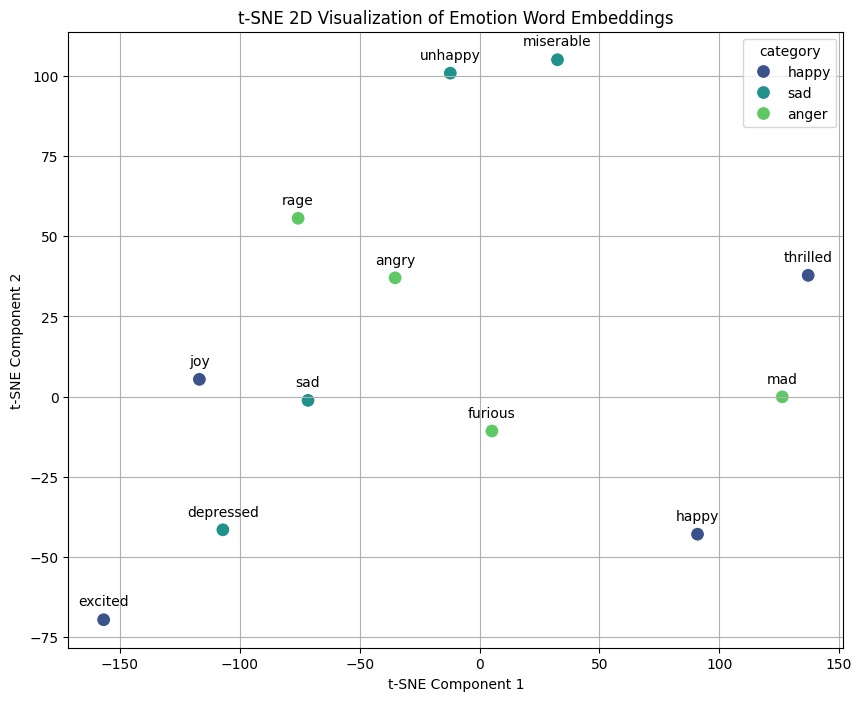

In [ ]:
from sklearn.manifold import TSNE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Perform t-SNE for 2D visualization
tsne_2d = TSNE(n_components=2, random_state=42, perplexity=5, learning_rate='auto', init='random', max_iter=2500) # Changed n_iter to max_iter
embeddings_2d = tsne_2d.fit_transform(embeddings_array)

# Perform t-SNE for 3D visualization
tsne_3d = TSNE(n_components=3, random_state=42, perplexity=5, learning_rate='auto', init='random', max_iter=2500) # Changed n_iter to max_iter
embeddings_3d = tsne_3d.fit_transform(embeddings_array)

# Create DataFrames for easier plotting
df_2d = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'word': words_list,
    'category': categories_list
})

df_3d = pd.DataFrame({
    'x': embeddings_3d[:, 0],
    'y': embeddings_3d[:, 1],
    'z': embeddings_3d[:, 2],
    'word': words_list,
    'category': categories_list
})

print(f"2D embeddings shape: {embeddings_2d.shape}")
print(f"3D embeddings shape: {embeddings_3d.shape}")
print("Created DataFrames for 2D and 3D visualizations.")

# Visualize 2D t-SNE embeddings
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_2d, x='x', y='y', hue='category', palette='viridis', s=100)
for i, row in df_2d.iterrows():
    plt.annotate(row['word'], (row['x'], row['y']), textcoords="offset points", xytext=(0,10), ha='center')
plt.title('t-SNE 2D Visualization of Emotion Word Embeddings')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

# Visualize 3D t-SNE embeddings
fig_3d = px.scatter_3d(df_3d, x='x', y='y', z='z', color='category', text='word',
                    title='t-SNE 3D Visualization of Emotion Word Embeddings', opacity=0.7)
fig_3d.update_traces(textposition='top center')
fig_3d.show()

In [ ]:
import torch
from transformers import DistilBertTokenizer, DistilBertModel
import numpy as np

# Re-initialize tokenizer and model if not already in session or for clarity
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased')

# New words to extract embeddings for
additional_words = ['sadness', 'love', 'like', 'hate', 'ecstatic']

# Extend the existing emotion_embeddings list
for word in additional_words:
    input_ids = tokenizer.encode(word, add_special_tokens=False, return_tensors='pt')

    if input_ids.shape[1] == 0:
        print(f"Warning: '{word}' not found in vocabulary. Skipping.")
        continue

    with torch.no_grad():
        outputs = model(input_ids)

    word_embedding = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

    emotion_embeddings.append({
        'word': word,
        'category': 'additional', # Assign a generic category for new words
        'embedding': word_embedding
    })

print(f"Extracted embeddings for {len(additional_words)} additional words.")
print(f"Total embeddings now: {len(emotion_embeddings)} words.")

# Create a dictionary for easy lookup
word_to_embedding = {item['word']: item['embedding'] for item in emotion_embeddings}

print(f"Created word_to_embedding dictionary with {len(word_to_embedding)} entries.")

Extracted embeddings for 5 additional words.
Total embeddings now: 17 words.
Created word_to_embedding dictionary with 17 entries.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def find_closest_words(target_embedding, word_embeddings_dict, top_n=5):
    """
    Calculates cosine similarity between a target embedding and all embeddings in the dictionary,
    returning the top N closest words.
    """
    similarities = []
    for word, embedding in word_embeddings_dict.items():
        if np.array_equal(target_embedding, embedding): # Skip the target word itself if it's in the dict
            continue
        # Reshape for cosine_similarity: (1, n_features) for the first arg, (m, n_features) for the second
        similarity = cosine_similarity(target_embedding.reshape(1, -1), embedding.reshape(1, -1))[0][0]
        similarities.append((word, similarity))

    # Sort by similarity in descending order
    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:top_n]

print("Helper function `find_closest_words` defined.")


Helper function `find_closest_words` defined.


In [ ]:
print("\n--- Analogy 1: happy - joy + sadness ---")

# Retrieve embeddings
embedding_happy = word_to_embedding['happy']
embedding_joy = word_to_embedding['joy']
embedding_sadness = word_to_embedding['sadness']

# Calculate the resulting vector
result_vector1 = embedding_happy - embedding_joy + embedding_sadness

# Find closest words
closest_words1 = find_closest_words(result_vector1, word_to_embedding, top_n=5)

print("Top 5 words closest to 'happy - joy + sadness':")
for word, similarity in closest_words1:
    print(f"- {word}: {similarity:.4f}")


--- Analogy 1: happy - joy + sadness ---
Top 5 words closest to 'happy - joy + sadness':
- happy: 0.7669
- sadness: 0.7541
- hate: 0.6372
- like: 0.5822
- mad: 0.5771


In [ ]:
print("\n--- Analogy 2: love - like + hate ---")

# Retrieve embeddings
embedding_love = word_to_embedding['love']
embedding_like = word_to_embedding['like']
embedding_hate = word_to_embedding['hate']

# Calculate the resulting vector
result_vector2 = embedding_love - embedding_like + embedding_hate

# Find closest words
closest_words2 = find_closest_words(result_vector2, word_to_embedding, top_n=5)

print("Top 5 words closest to 'love - like + hate':")
for word, similarity in closest_words2:
    print(f"- {word}: {similarity:.4f}")


--- Analogy 2: love - like + hate ---
Top 5 words closest to 'love - like + hate':
- hate: 0.8223
- love: 0.8154
- sadness: 0.6253
- unhappy: 0.5298
- rage: 0.5225


In [ ]:
print("\n--- Semantic Relationship: Emotion Intensity (ecstatic - happy) ---")

# Retrieve embeddings
embedding_ecstatic = word_to_embedding['ecstatic']
embedding_happy = word_to_embedding['happy']

# Calculate the difference vector (representing the 'intensity' or 'moreness' from happy to ecstatic)
difference_vector_intensity = embedding_ecstatic - embedding_happy

# Find closest words to this difference vector
closest_words_intensity = find_closest_words(difference_vector_intensity, word_to_embedding, top_n=3)

print("Top 3 words closest to 'ecstatic - happy' difference vector:")
for word, similarity in closest_words_intensity:
    print(f"- {word}: {similarity:.4f}")

print("\nInterpretation: This difference vector aims to capture the 'intensity' or 'degree' of happiness. The closest words should ideally reflect concepts related to heightened positive emotion or similar semantic shifts.")


--- Semantic Relationship: Emotion Intensity (ecstatic - happy) ---
Top 3 words closest to 'ecstatic - happy' difference vector:
- ecstatic: 0.3547
- unhappy: 0.0317
- rage: 0.0225

Interpretation: This difference vector aims to capture the 'intensity' or 'degree' of happiness. The closest words should ideally reflect concepts related to heightened positive emotion or similar semantic shifts.


In [ ]:
print("\n--- Semantic Relationship: Emotion Opposition (joy - sadness) ---")

# Retrieve embeddings
embedding_joy = word_to_embedding['joy']
embedding_sadness = word_to_embedding['sadness']

# Calculate the difference vector (representing the 'opposition' from sadness to joy)
difference_vector_opposition = embedding_joy - embedding_sadness

# Find closest words to this difference vector
closest_words_opposition = find_closest_words(difference_vector_opposition, word_to_embedding, top_n=3)

print("Top 3 words closest to 'joy - sadness' difference vector:")
for word, similarity in closest_words_opposition:
    print(f"- {word}: {similarity:.4f}")

print("\nInterpretation: This difference vector aims to capture the 'opposition' or 'polarity' between joy and sadness. The closest words should ideally reflect concepts related to positive emotions or the inverse of negative emotions.")


--- Semantic Relationship: Emotion Opposition (joy - sadness) ---
Top 3 words closest to 'joy - sadness' difference vector:
- joy: 0.3325
- happy: 0.1146
- furious: 0.1102

Interpretation: This difference vector aims to capture the 'opposition' or 'polarity' between joy and sadness. The closest words should ideally reflect concepts related to positive emotions or the inverse of negative emotions.


In [ ]:
import numpy as np

# 1. Initialize a dictionary to store average embeddings
average_embeddings = {}

# 2. Iterate through the all_emotion_words dictionary
for emotion_category, words in all_emotion_words.items():
    # 3a. Create an empty list to collect embeddings for the current category
    category_embeddings = []

    # 3b. Iterate through the words in the current emotion category
    for word in words:
        # 3c. Retrieve the embedding for each word
        if word in word_to_embedding:
            category_embeddings.append(word_to_embedding[word])
        else:
            print(f"Warning: Embedding for '{word}' not found. Skipping.")

    # 3e. Calculate the mean of these embeddings if there are any
    if category_embeddings:
        average_embeddings[emotion_category] = np.mean(category_embeddings, axis=0)
        print(f"Calculated average embedding for '{emotion_category}'. Shape: {average_embeddings[emotion_category].shape}")
    else:
        print(f"No embeddings found for category '{emotion_category}'.")

print("\nAverage embeddings calculated for all specified emotion categories.")
# Display the shape of average embeddings as an example
for category, avg_emb in average_embeddings.items():
    print(f"Category: {category}, Average Embedding Shape: {avg_emb.shape}")

Calculated average embedding for 'happy'. Shape: (768,)
Calculated average embedding for 'sad'. Shape: (768,)
Calculated average embedding for 'anger'. Shape: (768,)

Average embeddings calculated for all specified emotion categories.
Category: happy, Average Embedding Shape: (768,)
Category: sad, Average Embedding Shape: (768,)
Category: anger, Average Embedding Shape: (768,)


Centroid embeddings array shape: (3, 768)
Centroid categories: ['happy', 'sad', 'anger']
DataFrame for 2D centroids created.


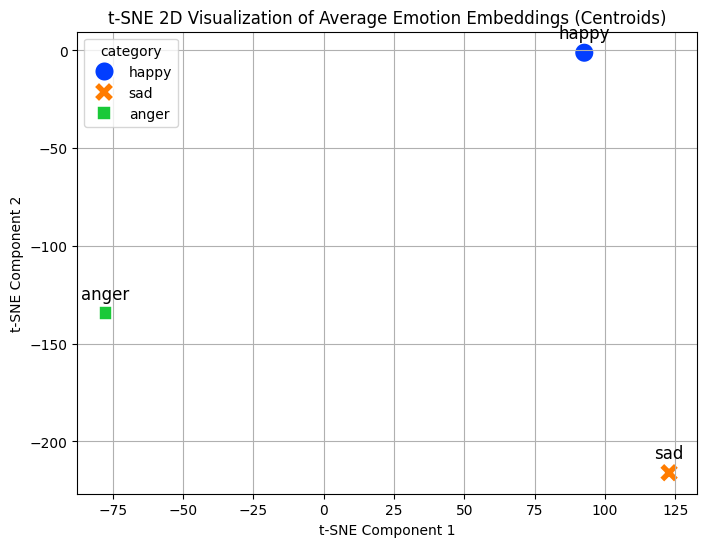

In [ ]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the average emotion embeddings for visualization
centroid_embeddings_array = np.array(list(average_embeddings.values()))
centroid_categories = list(average_embeddings.keys())

print(f"Centroid embeddings array shape: {centroid_embeddings_array.shape}")
print(f"Centroid categories: {centroid_categories}")

# 2. Apply t-SNE to reduce dimensionality of centroids to 2D
# Perplexity should be less than the number of samples for meaningful results, or None.
# With only 3 points, perplexity=None is appropriate, or a small value if it causes issues.
# Using min(n_samples - 1, 5) is a common heuristic, so 2 here if n_samples=3.
# However, 'auto' learning rate often requires perplexity. Let's set it to 2 directly.
tsne_centroids_2d = TSNE(n_components=2, random_state=42, perplexity=2, learning_rate='auto', init='random', max_iter=2500)
centroids_2d = tsne_centroids_2d.fit_transform(centroid_embeddings_array)

# 3. Create a Pandas DataFrame for 2D centroids
df_centroids_2d = pd.DataFrame({
    'x': centroids_2d[:, 0],
    'y': centroids_2d[:, 1],
    'category': centroid_categories
})

print("DataFrame for 2D centroids created.")

# 4. Generate a 2D scatter plot of emotion centroids
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_centroids_2d, x='x', y='y', hue='category', palette='bright', s=200, style='category', markers=True)
for i, row in df_centroids_2d.iterrows():
    plt.annotate(row['category'], (row['x'], row['y']), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=12)
plt.title('t-SNE 2D Visualization of Average Emotion Embeddings (Centroids)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

Calculated pairwise cosine similarity matrix.
Similarity matrix shape: (3, 3)
Created DataFrame for similarity matrix.
Similarity DataFrame:
           happy       sad     anger
happy  1.000000  0.797526  0.858773
sad    0.797526  1.000000  0.856564
anger  0.858773  0.856564  1.000000


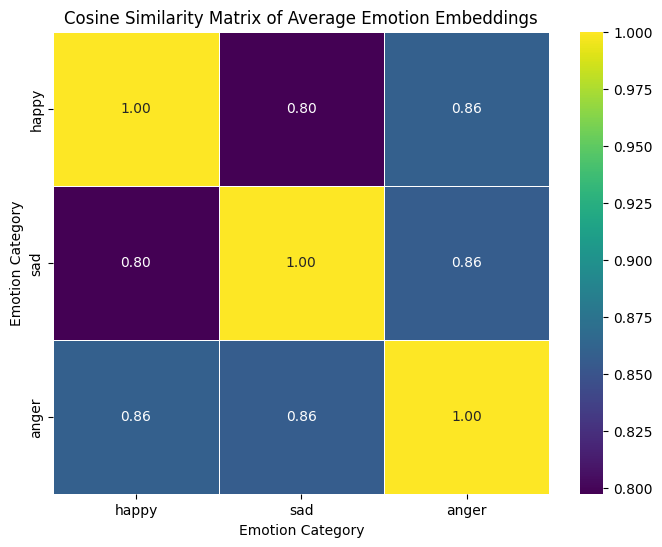

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# 5. Calculate the pairwise cosine similarity between each of the original average emotion embeddings
# The centroid_embeddings_array already contains the original (768-dimensional) average embeddings
similarity_matrix = cosine_similarity(centroid_embeddings_array)

print("Calculated pairwise cosine similarity matrix.")
print(f"Similarity matrix shape: {similarity_matrix.shape}")

# 6. Convert the similarity matrix into a Pandas DataFrame
df_similarity = pd.DataFrame(
    similarity_matrix,
    index=centroid_categories,
    columns=centroid_categories
)

print("Created DataFrame for similarity matrix.")
print("Similarity DataFrame:\n", df_similarity)

# 7. Visualize this emotion similarity matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_similarity, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Cosine Similarity Matrix of Average Emotion Embeddings')
plt.xlabel('Emotion Category')
plt.ylabel('Emotion Category')
plt.show()

In [ ]:
import torch
from transformers import DistilBertTokenizer, DistilBertModel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Re-initialize tokenizer and model for clarity, ensuring output_attentions is handled
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased', output_attentions=True)

# 1. Select a sample emotion-laden sentence
sentence = "I feel incredibly angry about this situation."

# 2. Tokenize the sentence
# add_special_tokens=True will add [CLS] and [SEP] tokens
# return_tensors='pt' will return PyTorch tensors
input_ids = tokenizer.encode(sentence, add_special_tokens=True, return_tensors='pt')
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

print(f"Original sentence: {sentence}")
print(f"Tokenized input IDs: {input_ids}")
print(f"Tokens: {tokens}")

Original sentence: I feel incredibly angry about this situation.
Tokenized input IDs: tensor([[  101,  1045,  2514, 11757,  4854,  2055,  2023,  3663,  1012,   102]])
Tokens: ['[CLS]', 'i', 'feel', 'incredibly', 'angry', 'about', 'this', 'situation', '.', '[SEP]']


In [ ]:
import torch

# 3. Pass the tokenized input to the DistilBertModel to retrieve attention weights
with torch.no_grad():
    outputs = model(input_ids)

# 4. Extract attention weights from the last layer and average across heads
# outputs.attentions is a tuple of (layer_output_attention_tensor, ...)
# Each tensor has shape (batch_size, num_heads, sequence_length, sequence_length)

# Get attention from the last layer (e.g., outputs.attentions[-1])
# For DistilBERT, there are 6 layers, so the last is index 5
last_layer_attention = outputs.attentions[-1]

# Average across all attention heads
# Shape: (batch_size, sequence_length, sequence_length)
attention_matrix = last_layer_attention.mean(dim=1).squeeze(0).numpy()

print(f"Attention matrix shape: {attention_matrix.shape}")
print("Extracted and averaged attention weights.")

Attention matrix shape: (10, 10)
Extracted and averaged attention weights.


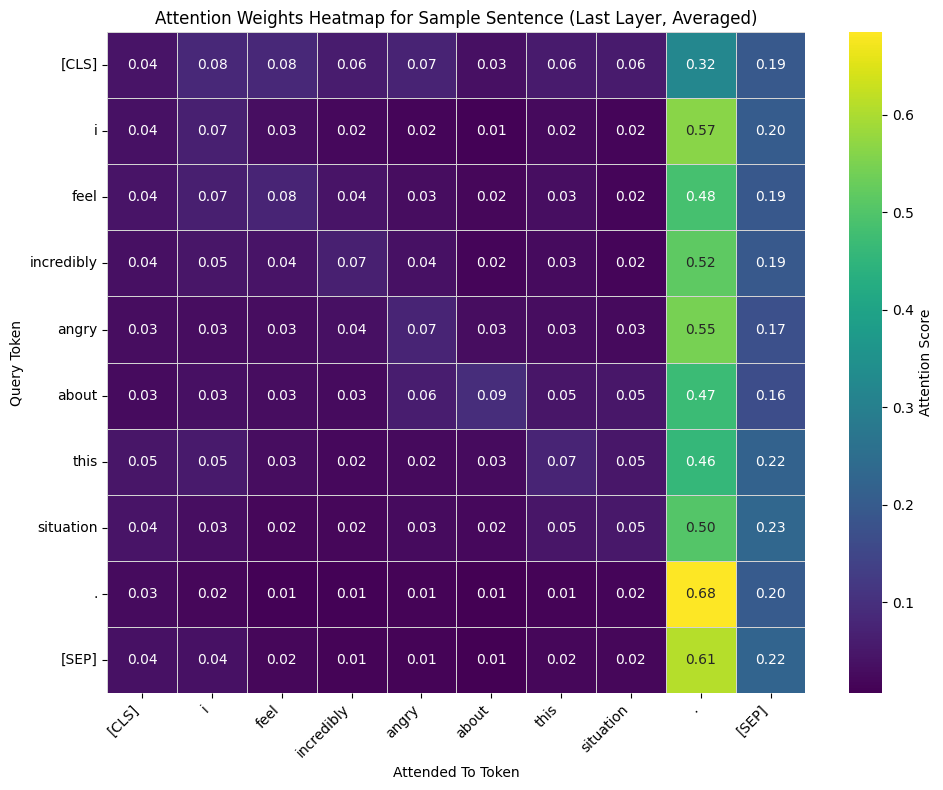

Heatmap visualization of attention weights generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Create a heatmap visualization of this attention matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    attention_matrix,
    xticklabels=tokens,
    yticklabels=tokens,
    cmap='viridis',
    linewidths=.5,
    linecolor='lightgray',
    annot=True, # Display the attention values on the heatmap
    fmt='.2f', # Format annotation to two decimal places
    cbar_kws={'label': 'Attention Score'}
)
plt.title('Attention Weights Heatmap for Sample Sentence (Last Layer, Averaged)')
plt.xlabel('Attended To Token')
plt.ylabel('Query Token')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. Analyze the heatmap (This will be a markdown cell after the plot)
print("Heatmap visualization of attention weights generated.")